In [1]:
import pandas as pd 
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("data/donnees_immobilieres.xlsx")

In [3]:
df.head()

,ID,Surface_m2,Chambres,Annee_construction,Distance_centre_km,Etage,Ascenseur,Annee_vente,Qualite_ecole,Revenu_median_quartier,Distance_universite,Prix_milliers_euros
0,1,139.87,3,1982,21.33,2,1,2023,1.1,47.5,11.9,1961.68
1,2,114.47,4,1991,2.90,5,1,2022,4.7,44.2,11.9,2303.67
2,3,145.91,2,2005,3.00,3,1,2017,3.2,53.8,10.7,2224.12
3,4,180.92,4,1995,29.61,3,1,2022,6.1,68.3,11.1,2425.63
4,5,110.63,3,2016,11.54,0,0,2021,9.0,81.9,10.8,2323.34


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      150 non-null    int64  
 1   Surface_m2              150 non-null    float64
 2   Chambres                150 non-null    int64  
 3   Annee_construction      150 non-null    int64  
 4   Distance_centre_km      150 non-null    float64
 5   Etage                   150 non-null    int64  
 6   Ascenseur               150 non-null    int64  
 7   Annee_vente             150 non-null    int64  
 8   Qualite_ecole           150 non-null    float64
 9   Revenu_median_quartier  150 non-null    float64
 10  Distance_universite     150 non-null    float64
 11  Prix_milliers_euros     150 non-null    float64
dtypes: float64(6), int64(6)
memory usage: 14.2 KB


In [5]:
df.describe()

,ID,Surface_m2,Chambres,Annee_construction,Distance_centre_km,Etage,Ascenseur,Annee_vente,Qualite_ecole,Revenu_median_quartier,Distance_universite,Prix_milliers_euros
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,116.706800,2.886667,2001.826667,16.500267,2.580000,0.460000,2019.840000,5.468667,63.668000,8.064000,2107.904800
std,43.445368,37.693819,1.077760,11.704841,9.017430,1.761901,0.500067,2.288225,1.868249,9.295458,3.746502,229.921013
min,1.000000,15.210000,1.000000,1980.000000,0.830000,0.000000,0.000000,2015.000000,1.000000,42.900000,1.000000,1500.770000
25%,38.250000,93.240000,2.000000,1991.000000,9.105000,1.000000,0.000000,2018.000000,4.125000,57.500000,5.300000,1934.285000
50%,75.500000,117.845000,3.000000,2002.500000,16.865000,2.500000,0.000000,2020.000000,5.600000,63.450000,8.300000,2105.050000
75%,112.750000,139.637500,4.000000,2012.000000,24.697500,4.000000,1.000000,2022.000000,7.000000,70.475000,10.875000,2272.780000
max,150.000000,218.530000,5.000000,2022.000000,29.990000,5.000000,1.000000,2023.000000,10.000000,83.900000,17.100000,2743.040000


In [6]:
df.skew(numeric_only=True)


ID                        0.000000
Surface_m2                0.047717
Chambres                  0.098146
Annee_construction       -0.082919
Distance_centre_km       -0.141943
Etage                    -0.011300
Ascenseur                 0.162140
Annee_vente              -0.321855
Qualite_ecole            -0.145050
Revenu_median_quartier    0.051913
Distance_universite      -0.116417
Prix_milliers_euros       0.156231
dtype: float64

In [7]:
df.kurtosis(numeric_only=True)

ID                       -1.200000
Surface_m2               -0.106039
Chambres                 -0.690451
Annee_construction       -1.165682
Distance_centre_km       -1.192008
Etage                    -1.336060
Ascenseur                -2.000566
Annee_vente              -1.005823
Qualite_ecole            -0.496161
Revenu_median_quartier   -0.580403
Distance_universite      -0.629394
Prix_milliers_euros      -0.468721
dtype: float64

**VISUALISATION**

In [8]:
sns.set_style("ticks")

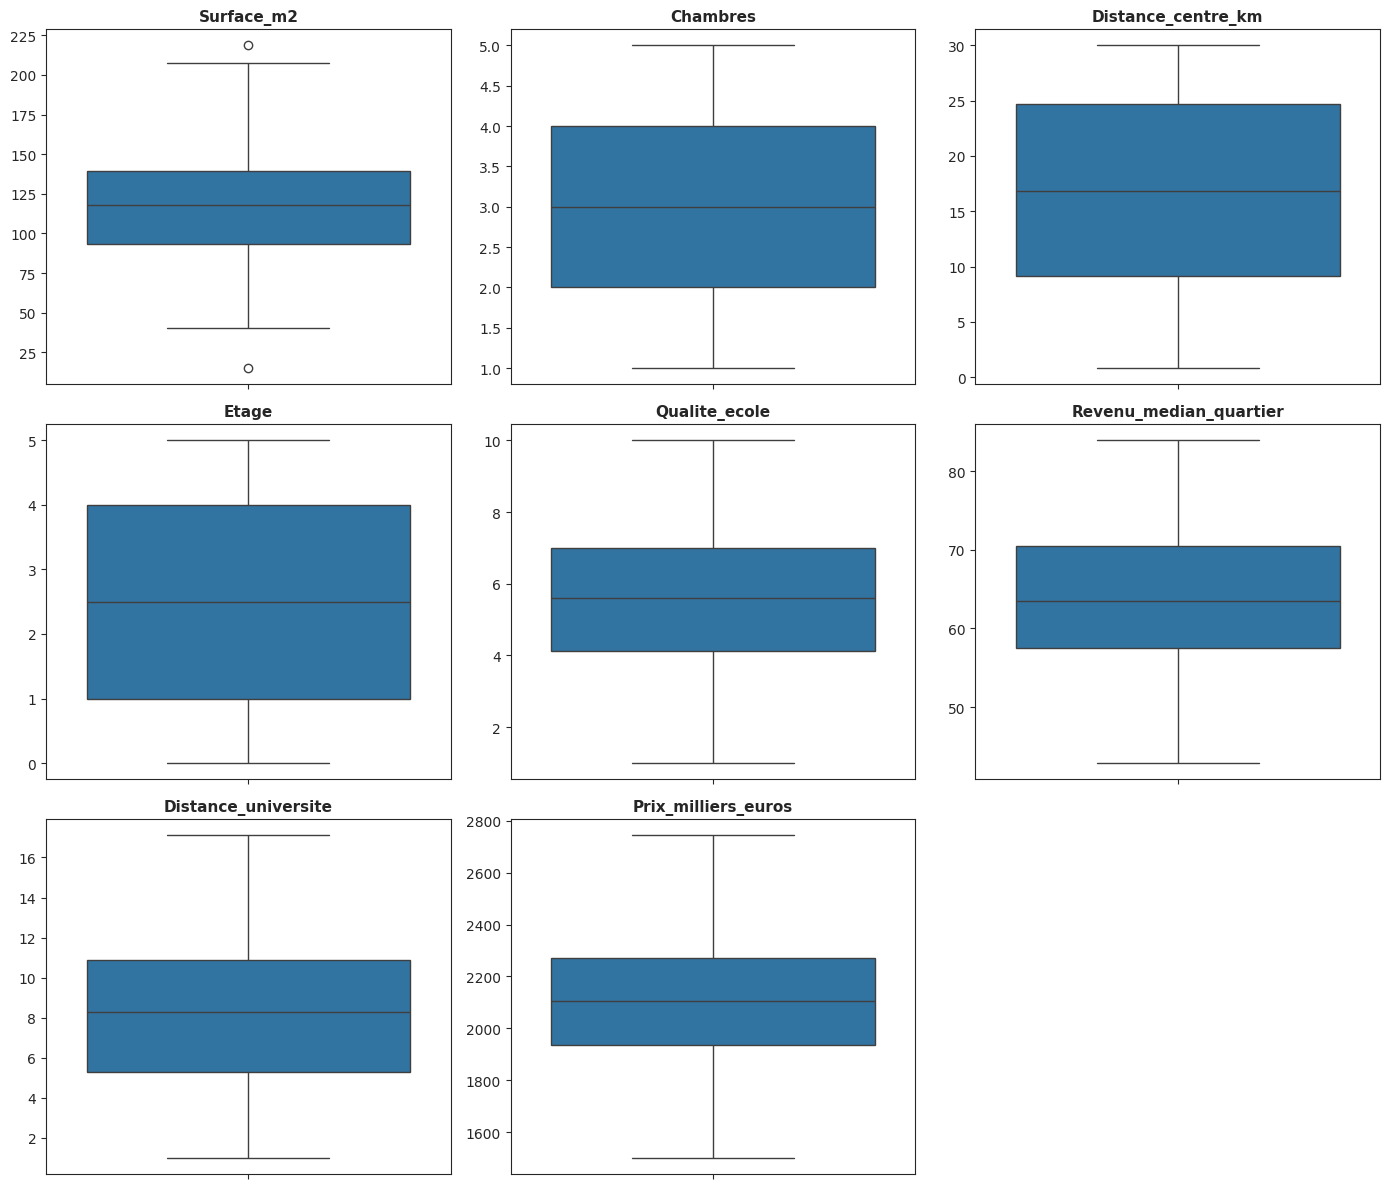

In [9]:
cols_to_plot = [
    "Surface_m2",
    "Chambres",
    "Distance_centre_km",
    "Etage",
    "Qualite_ecole",
    "Revenu_median_quartier",
    "Distance_universite",
    "Prix_milliers_euros"
]

n_cols = 3
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col, fontsize=11, weight="bold")
    ax.set_ylabel("")

# Masquer les axes inutilisés
for ax in axes[len(cols_to_plot):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

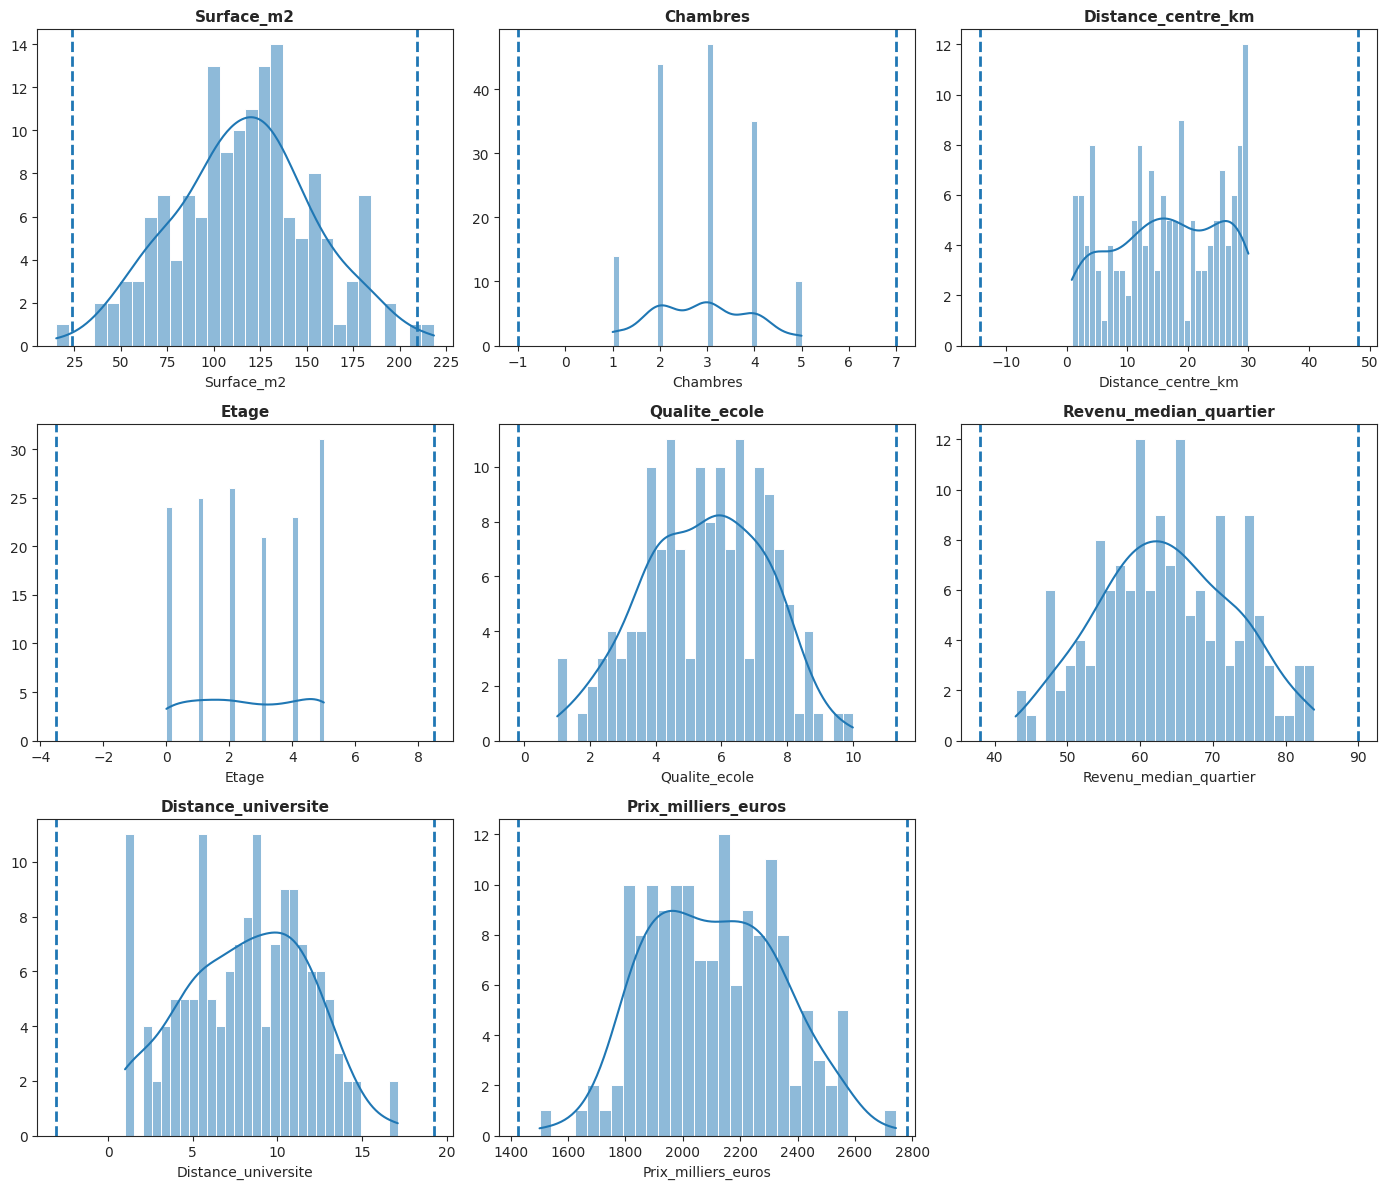

In [10]:
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    data = df[col].dropna()

    # Histogramme + KDE
    sns.histplot(data, bins=30, kde=True, ax=ax)

    # Calcul des outliers (IQR)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Lignes des seuils
    ax.axvline(lower, linestyle="--", linewidth=2, label="Outlier seuil")
    ax.axvline(upper, linestyle="--", linewidth=2)

    ax.set_title(col, fontsize=11, weight="bold")
    ax.set_ylabel("")

# Masquer les axes inutilisés
for ax in axes[len(cols_to_plot):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("hist.png", dpi=300, bbox_inches="tight")
plt.show()


**ANALYSE DE CORRELATION**

In [11]:
continuous_cols = [
    "Surface_m2",
    "Distance_centre_km",
    "Revenu_median_quartier",
    "Distance_universite",
    "Prix_milliers_euros",
    "Annee_vente",
    "Annee_construction"
]

In [12]:
corr = df[continuous_cols].corr(numeric_only=True)  # par défaut: Pearson

In [13]:
corr

,Surface_m2,Distance_centre_km,Revenu_median_quartier,Distance_universite,Prix_milliers_euros,Annee_vente,Annee_construction
Surface_m2,1.000000,-0.074765,0.013908,-0.088362,0.826731,0.060417,-0.034333
Distance_centre_km,-0.074765,1.000000,0.111579,-0.055751,-0.306648,0.076058,-0.088117
Revenu_median_quartier,0.013908,0.111579,1.000000,-0.304002,0.205779,0.007267,0.030304
Distance_universite,-0.088362,-0.055751,-0.304002,1.000000,-0.124521,0.033378,-0.006250
Prix_milliers_euros,0.826731,-0.306648,0.205779,-0.124521,1.000000,0.236992,0.068358
Annee_vente,0.060417,0.076058,0.007267,0.033378,0.236992,1.000000,-0.055920
Annee_construction,-0.034333,-0.088117,0.030304,-0.006250,0.068358,-0.055920,1.000000


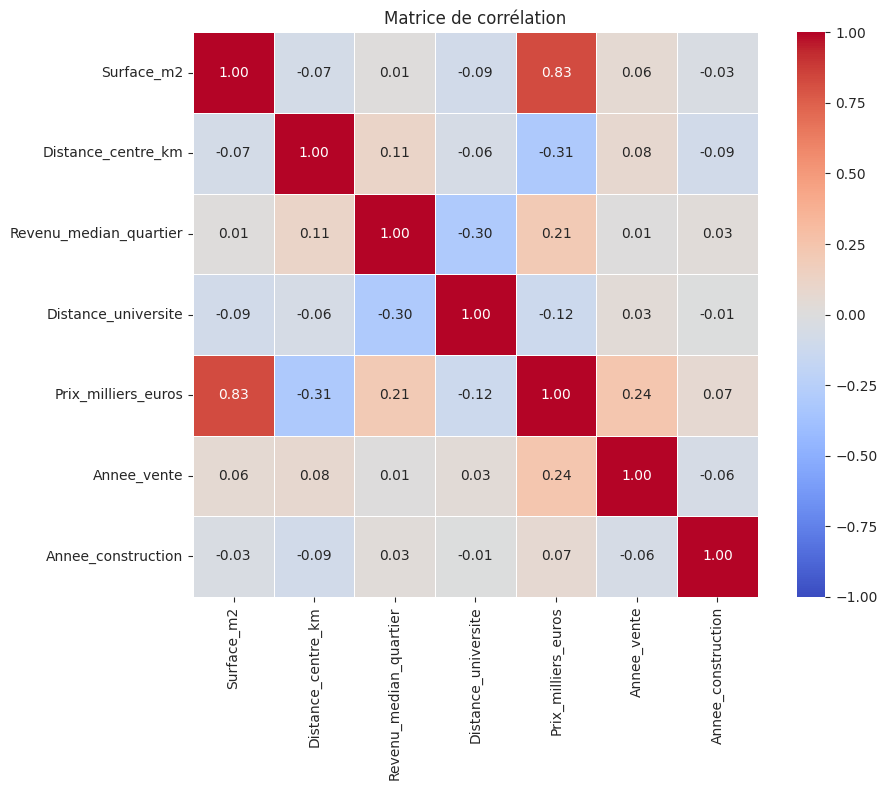

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # affiche les valeurs
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
X = df["Surface_m2"]
X= sm.add_constant(X)
y = df["Prix_milliers_euros"]

In [16]:
model = sm.OLS(y, X)
results = model.fit()

In [18]:
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:     Prix_milliers_euros   R-squared:                       0.683
Model:                             OLS   Adj. R-squared:                  0.681
Method:                  Least Squares   F-statistic:                     319.6
Date:                 Mon, 15 Dec 2025   Prob (F-statistic):           8.45e-39
Time:                         23:44:36   Log-Likelihood:                -941.72
No. Observations:                  150   AIC:                             1887.
Df Residuals:                      148   BIC:                             1893.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1519.3743     34.584     43.93

In [20]:
X = df[[
    "Surface_m2",
    "Chambres",
    "Annee_construction",
    "Distance_centre_km",
    "Etage",
    "Ascenseur"
]]



In [21]:
X = sm.add_constant(X)
y = df["Prix_milliers_euros"]

In [22]:
model = sm.OLS(y, X)
results = model.fit()

In [23]:
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:     Prix_milliers_euros   R-squared:                       0.789
Model:                             OLS   Adj. R-squared:                  0.780
Method:                  Least Squares   F-statistic:                     88.94
Date:                 Tue, 16 Dec 2025   Prob (F-statistic):           9.10e-46
Time:                         01:01:49   Log-Likelihood:                -911.43
No. Observations:                  150   AIC:                             1837.
Df Residuals:                      143   BIC:                             1858.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -1679.4